In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# mask = cat['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
cat['q'] = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
cat['q'] &= cat['Z']<1.5
cat['q'] &= cat['ZWARN']<1.5

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701


In [4]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# mask = cat_1x['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat_1x = cat_1x[~mask_bad]
# print(len(cat_1x), len(np.unique(cat_1x['TARGETID'])))

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat_1x['Z']))
cat_1x['q'] = ((cat_1x['DELTACHI2']>d) & (cat_1x['DELTACHI2']>10)) | (cat_1x['DELTACHI2']>30)
cat_1x['q'] &= cat_1x['Z']<1.5
cat_1x['q'] &= cat_1x['ZWARN']<1.5

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194


In [5]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [6]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(deep['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# deep = deep[~mask_bad]
# print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

deep_all = deep.copy()
# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*deep_all['Z']))
deep_all['q'] = ((deep_all['DELTACHI2']>d) & (deep_all['DELTACHI2']>10)) | (deep_all['DELTACHI2']>30)
deep_all['q'] &= deep_all['Z']<1.5
deep_all['q'] &= deep_all['ZWARN']<1.5

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep[deep_columns_new], keys='TARGETID')

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
39533 39533
Min depth 30377 9156 0.768396023575241


In [7]:
# main = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# mask = main['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(main['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# main = main[~mask_bad]
# print(len(main), len(np.unique(main['TARGETID'])))

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*main['Z']))
main['q'] = ((main['DELTACHI2']>d) & (main['DELTACHI2']>10)) | (main['DELTACHI2']>30)
main['q'] &= main['Z']<1.5
main['q'] &= main['ZWARN']<1.5

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046


---------

In [8]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also reject objects with ZWARN!=0 or z>1.4 or DELTACHI2<15 in the deep coadds
mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.5)
mask_deep_fail = ~mask_deep
# mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.5) & (cat['DELTACHI2_deep']>30)
mask_fail |= mask_deep_fail
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
print()

mask = cat['main_lrg'].copy()
print('Catastrophic failure rate (all): {:.1f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))
mask &= cat['EFFTIME_LRG']>800
print('Catastrophic failure rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

71305 0.1888899190717758
71633 0.18975880475238083

Catastrophic failure rate (all): 10.7% (11204/104428)
Catastrophic failure rate (EFFTIME>800s): 0.8% (139/18370)


In [9]:
print(np.sum(~cat['q']), np.sum(~cat['q'])/len(cat))
mask = cat['EFFTIME_LRG']>800
# Failures in "good redshifts"
print(np.sum(mask_fail & cat['q'] & mask), np.sum(mask_fail & cat['q'] & mask)/np.sum(cat['q'] & mask))
print()

print('Main LRGs in SV:')
mask = cat['main_lrg'].copy()
print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~cat['q']) & mask)/np.sum(mask), np.sum((~cat['q']) & mask), np.sum(mask)))
mask &= cat['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum((~cat['q']) & mask)/np.sum(mask), np.sum((~cat['q']) & mask), np.sum(mask)))
print('Catastrophic failure rate in accepted redshifts (EFFTIME>800s): {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & cat['q'] & mask)/np.sum(cat['q'] & mask), np.sum(mask_fail & cat['q'] & mask), np.sum(cat['q'] & mask)))

101255 0.268228718261169
269 0.004309516180711311

Main LRGs in SV:
Rejection rate (all): 15.4% (16090/104428)
Rejection rate (EFFTIME>800s): 0.9% (165/18370)
Catastrophic failure rate in accepted redshifts (EFFTIME>800s): 0.23% (42/18205)


In [10]:
print('Main LRGs in Main Survey:')
print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum(~main['q'])/len(main), np.sum(~main['q']), len(main)))
mask = main['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum((~main['q']) & mask)/np.sum(mask), np.sum((~main['q']) & mask), np.sum(mask)))

Main LRGs in Main Survey:
Rejection rate (all): 1.2% (3514/299639)
Rejection rate (EFFTIME>800s): 1.1% (3169/288287)


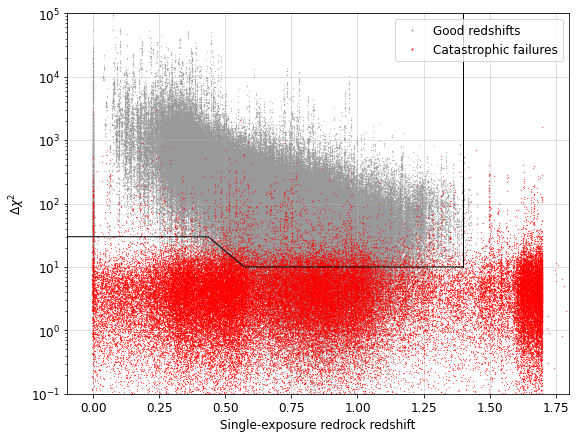

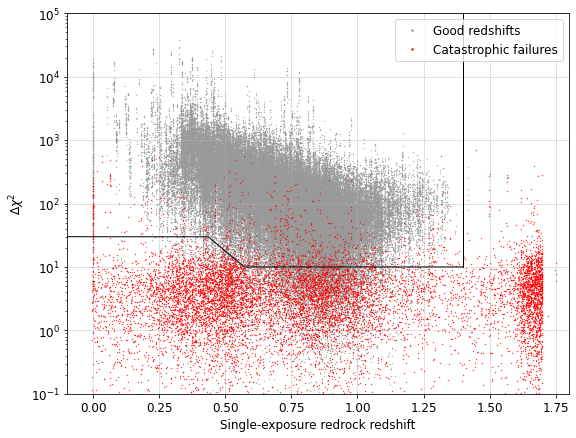

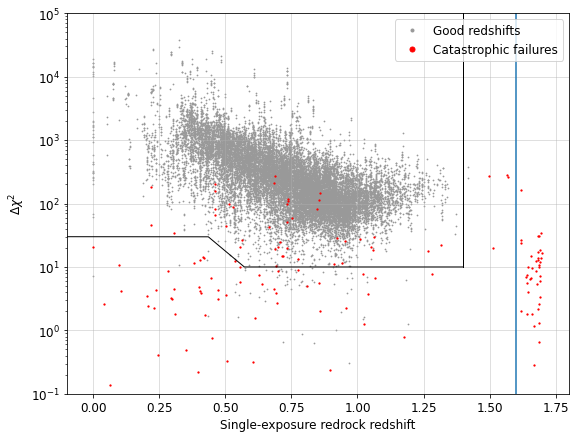

In [11]:
x = np.linspace(-1, 1.4, 10000)
y = np.ones_like(x)
y = (10**(3 - 3.5*x))
y[y<10] = 10
y[y>30] = 30

y1 = np.linspace(10, 1e6)
x1 = np.ones_like(y1) * 1.4

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.7, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.7, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.axvline(1.6)
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

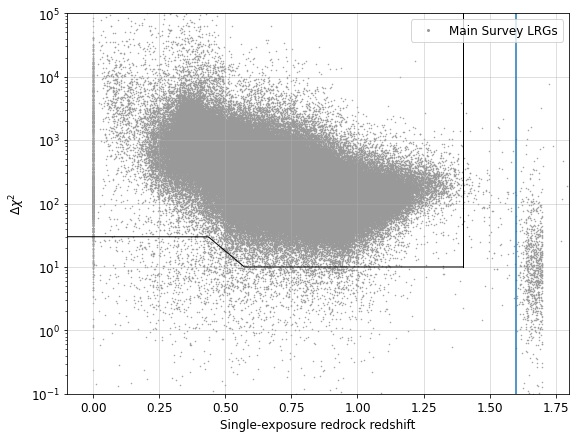

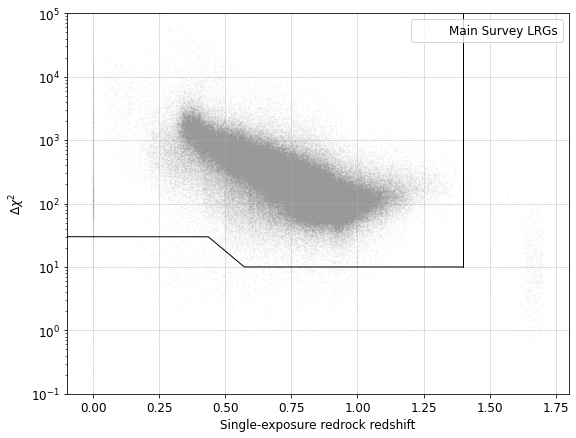

In [12]:
mask = main['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(main['Z'][mask], main['DELTACHI2'][mask], '.', color='0.6', ms=1., alpha=1., label='Main Survey LRGs', zorder=1)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.axvline(1.6)
plt.grid(alpha=0.5)
plt.show()

mask = main['EFFTIME_LRG']>800
plt.figure(figsize=(9, 7))
plt.plot(main['Z'][mask], main['DELTACHI2'][mask], '.', color='0.6', ms=0.5, alpha=.1, label='Main Survey LRGs', zorder=1)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [13]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

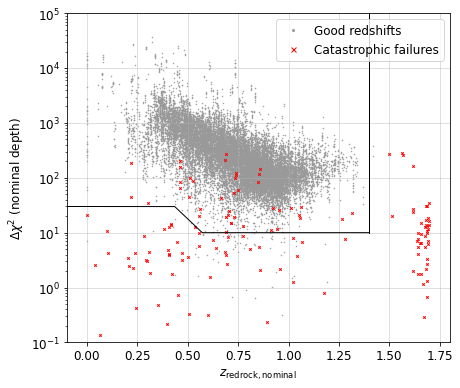

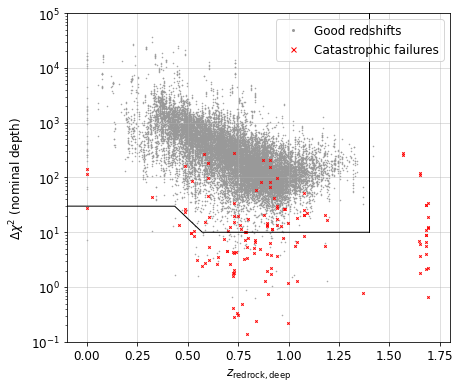

In [14]:
mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock,nominal}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z.pdf', dpi=150)
plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('$z_\mathrm{redrock,deep}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep.pdf', dpi=150)
plt.show()

In [15]:
# mask = (cat['EFFTIME_LRG']>800) & (cat['zfibermag']<21.8)
# mask1 = mask & (cat['main_lrg'])
# mask2 = mask & (~cat['main_lrg'])
# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Single-exposure redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z-1.pdf', dpi=200)
# plt.show()

# plt.figure(figsize=(6.5, 5.5))
# plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
# plt.plot(cat['Z_deep'][mask1 & mask_fail], cat['DELTACHI2'][mask1 & mask_fail], 'rx', ms=3., alpha=1, label='Catastrophic failures', zorder=3, rasterized=True)
# plt.plot(cat['Z_deep'][mask2 & mask_fail], cat['DELTACHI2'][mask2 & mask_fail], '.', color='darkorange', ms=1., alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
# plt.plot(x, y, color='k', lw=1)
# plt.plot(x1, y1, color='k', lw=1)
# # plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
# plt.yscale('log')
# plt.xlabel('Deep redrock redshift')
# plt.ylabel('$\Delta \chi^2$')
# plt.axis([-0.1, 1.8, .1, 100000])
# plt.legend(markerscale=1, loc='upper right')
# plt.grid(alpha=0.5)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_z_deep-1.pdf', dpi=150)
# plt.show()

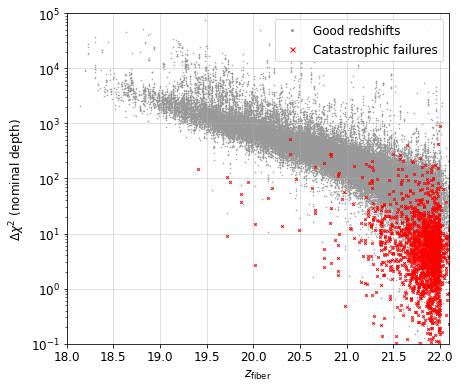

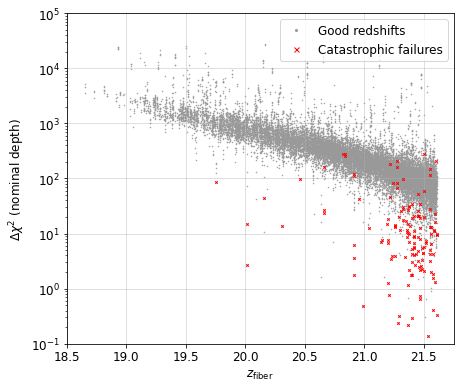

In [16]:
mask = cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18., 22.1, .1, 100000])
plt.axvline(1.4, color='k')
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

mask = cat['main_lrg'].copy()
mask &= cat['EFFTIME_LRG']>800
plt.figure(figsize=(6.5, 5.5))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, zorder=1, rasterized=True)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'rx', ms=2.5, alpha=1, zorder=2, rasterized=True)
plt.plot(-1, 0, '.', color='0.6', ms=4, alpha=1, label='Good redshifts', zorder=1, rasterized=True)
plt.plot(-1, 0, 'rx', ms=5, alpha=1, label='Catastrophic failures', zorder=2, rasterized=True)
plt.yscale('log')
plt.xlabel('$z_\mathrm{fiber}$')
plt.ylabel('$\Delta \chi^2$ (nominal depth)')
plt.axis([18.5, 21.75, .1, 100000])
plt.axvline(1.4, color='k')
plt.legend(markerscale=1, loc='upper right')
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dchi2_vs_zfiber.pdf', dpi=150)
plt.show()

In [17]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

## Failures rates vs EFFTIME

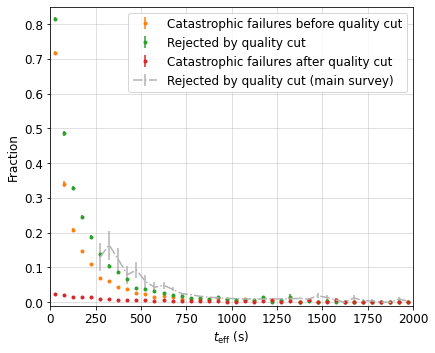

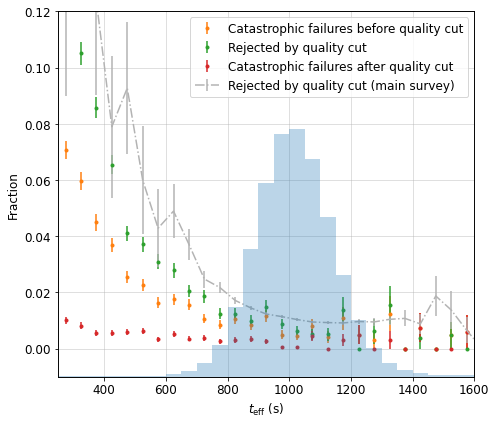

In [18]:
mask = cat['main_lrg'].copy()
bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (cat['q'] & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['EFFTIME_LRG'], (~main['q']), bin_edges, minsize=10, error_floor=False)

plt.figure(figsize=(6.5, 5.5))
plt.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quality cut')
plt.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
plt.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quality cut')
plt.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
# plt.xlabel('EFFTIME_LRG')
plt.xlabel('$t_\mathrm{eff}$ (s)')
plt.ylabel('Fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
# plt.title('Main LRGs')
plt.axis([0, 2000, -0.01, 0.85])
plt.show()

fig, ax = plt.subplots(figsize=(7., 6.))
ax1 = ax
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quality cut')
ax1.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quality cut')
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(main['EFFTIME_LRG'], bins=bin_edges, color='C0', alpha=0.3, label=None)
ax2.set_ylim(0, 70000)
ax2.yaxis.set_visible(False)
# ax1.xlabel('EFFTIME_LRG')
ax1.set_xlabel('$t_\mathrm{eff}$ (s)')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper right')
# ax1.title('Main LRGs')
ax1.axis([250, 1600, -0.01, 0.12])
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_efftime.pdf')
plt.show()

## Failures rates vs zfiber at nominal conditions

In [19]:
mask_nominal = (cat['EFFTIME_LRG']>800.) & (cat['EFFTIME_LRG']<1200.)
mask_nominal_main = (main['EFFTIME_LRG']>800.) & (main['EFFTIME_LRG']<1200.)
print('Nominal depth', np.sum(mask_nominal), np.sum(~mask_nominal), np.sum(mask_nominal)/len(mask_nominal))
print('Nominal depth (main)', np.sum(mask_nominal_main), np.sum(~mask_nominal_main), np.sum(mask_nominal_main)/len(mask_nominal_main))

Nominal depth 55913 321582 0.14811586908435873
Nominal depth (main) 260710 38929 0.8700803299970965


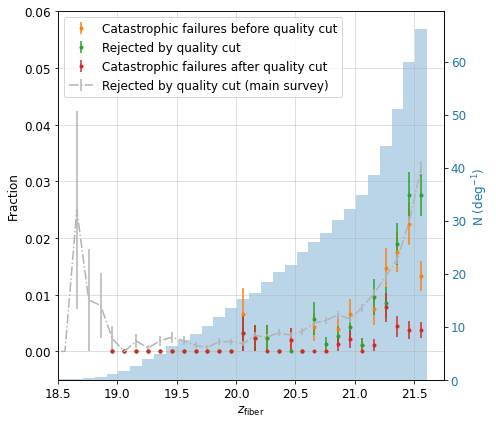

In [20]:
bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

area = len(main)/600

mask = cat['main_lrg'].copy()
mask &= mask_nominal
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q'])[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_fail_rate, bin_fail_rate_err = binned_frac(cat['zfibermag'][mask], mask_fail[mask], bin_edges, minsize=10, error_floor=False)
bin_center, bin_still_fail_rate, bin_still_fail_rate_err = binned_frac(cat['zfibermag'][mask], (cat['q'] & mask_fail)[mask], bin_edges, minsize=10, error_floor=False)

mask = mask_nominal_main.copy()
bin_center_main, bin_reject_rate_main, bin_reject_rate_err_main = binned_frac(main['zfibermag'][mask], (~main['q'])[mask], bin_edges, minsize=10, error_floor=False)


fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_fail_rate, color='C1',
             yerr=(np.clip(bin_fail_rate_err, None, bin_fail_rate), bin_fail_rate_err),
             fmt='.', label='Catastrophic failures before quality cut')
ax1.errorbar(bin_center, bin_reject_rate, color='C2',
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='.', label='Rejected by quality cut')
ax1.errorbar(bin_center, bin_still_fail_rate, color='C3',
             yerr=(np.clip(bin_still_fail_rate_err, None, bin_still_fail_rate), bin_still_fail_rate_err),
             fmt='.', label='Catastrophic failures after quality cut')
ax1.errorbar(bin_center_main, bin_reject_rate_main,
             yerr=(np.clip(bin_reject_rate_err_main, None, bin_reject_rate_main), bin_reject_rate_err_main),
             fmt='-.', label='Rejected by quality cut (main survey)', color='0.7')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Fraction')
ax1.grid(alpha=0.5)
ax1.legend(loc='upper left')
# ax1.title('Main LRGs')
ax1.axis([18.5, 21.75, -0.005, 0.06])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(main['zfibermag'], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(len(main), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_vs_zfiber.pdf')
plt.show()

## Success rates in 2D

In [21]:
# Include Main LRGs from SV
all_lrg = vstack([cat[cat['main_lrg']], main], join_type='inner')

print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~all_lrg['q']))/len(all_lrg['q']), np.sum((~all_lrg['q'])), len(all_lrg['q'])))
mask = all_lrg['EFFTIME_LRG']>800
print('Rejection rate (EFFTIME>800s): {:.1f}% ({}/{})'.format(100*np.sum((~all_lrg['q']) & mask)/np.sum(mask), np.sum((~all_lrg['q']) & mask), np.sum(mask)))

Rejection rate (all): 4.9% (19604/404067)
Rejection rate (EFFTIME>800s): 1.1% (3334/306657)


/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_40872/3803451698.py:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


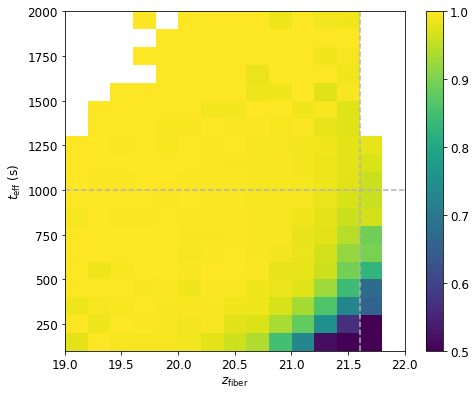

In [22]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(all_lrg['zfibermag'], all_lrg['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = all_lrg['q'].copy()
count_2d_good = np.histogram2d(all_lrg['zfibermag'][mask], all_lrg['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_40872/3803451698.py:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


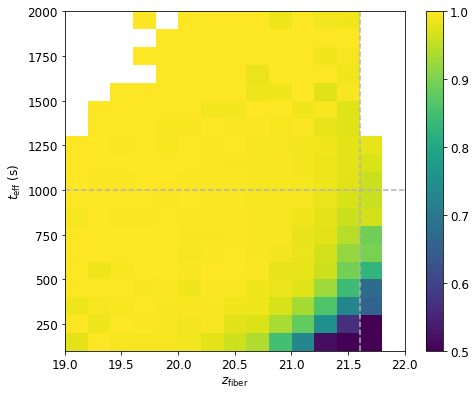

In [23]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(all_lrg['zfibermag'], all_lrg['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = all_lrg['q'].copy()
count_2d_good = np.histogram2d(all_lrg['zfibermag'][mask], all_lrg['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

__Add SV1 LRGs from deep coadds__

In [24]:
mask1 = all_lrg['zfibermag']<=21.6
mask2 = deep_all['zfibermag']>21.6
mask3 = cat['zfibermag']>21.6
lrg1 = vstack([all_lrg[mask1], deep_all[mask2], cat[mask3]], join_type='inner')
# lrg1 = vstack([cat, main], join_type='inner')

In [25]:
print('Rejection rate (all): {:.1f}% ({}/{})'.format(100*np.sum((~lrg1['q']))/len(lrg1['q']), np.sum((~lrg1['q'])), len(lrg1['q'])))
mask = lrg1['EFFTIME_LRG']>3000
print('Rejection rate (EFFTIME>300s): {:.1f}% ({}/{})'.format(100*np.sum((~lrg1['q']) & mask)/np.sum(mask), np.sum((~lrg1['q']) & mask), np.sum(mask)))

Rejection rate (all): 15.7% (85631/546284)
Rejection rate (EFFTIME>300s): 1.1% (113/10479)


/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_40872/3429409964.py:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all
/var/folders/p9/q1f79whn6670tx6f2ngp9t140000gn/T/ipykernel_40872/3429409964.py:9: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


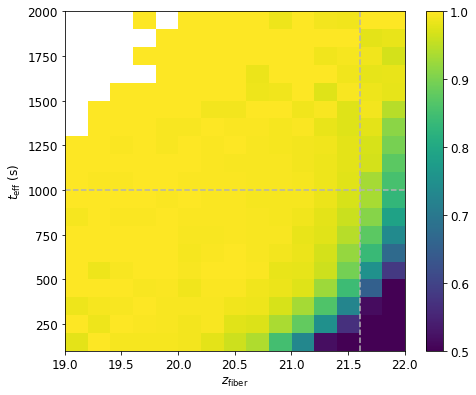

In [26]:
zfiber_bin_edges = np.linspace(18., 22., 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(lrg1['zfibermag'], lrg1['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = lrg1['q'].copy()
count_2d_good = np.histogram2d(lrg1['zfibermag'][mask], lrg1['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d = count_2d_good/count_2d_all
success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/failure_rate_in_2d.pdf')
plt.show()